
1D dirichlet 8x8):
 [[-0.5   0.25  0.    0.    0.    0.    0.    0.  ]
 [ 0.25 -0.5   0.25  0.    0.    0.    0.    0.  ]
 [ 0.    0.25 -0.5   0.25  0.    0.    0.    0.  ]
 [ 0.    0.    0.25 -0.5   0.25  0.    0.    0.  ]
 [ 0.    0.    0.    0.25 -0.5   0.25  0.    0.  ]
 [ 0.    0.    0.    0.    0.25 -0.5   0.25  0.  ]
 [ 0.    0.    0.    0.    0.    0.25 -0.5   0.25]
 [ 0.    0.    0.    0.    0.    0.    0.25 -0.5 ]]

1D periodic (8x8):
 [[-0.5   0.25  0.    0.    0.    0.    0.    0.25]
 [ 0.25 -0.5   0.25  0.    0.    0.    0.    0.  ]
 [ 0.    0.25 -0.5   0.25  0.    0.    0.    0.  ]
 [ 0.    0.    0.25 -0.5   0.25  0.    0.    0.  ]
 [ 0.    0.    0.    0.25 -0.5   0.25  0.    0.  ]
 [ 0.    0.    0.    0.    0.25 -0.5   0.25  0.  ]
 [ 0.    0.    0.    0.    0.    0.25 -0.5   0.25]
 [ 0.25  0.    0.    0.    0.    0.    0.25 -0.5 ]]

2D dirichlet (16x16):
 [[-0.5    0.125  0.     0.     0.125  0.     0.     0.     0.     0.
   0.     0.     0.     0.     0.     0.   ]
 [

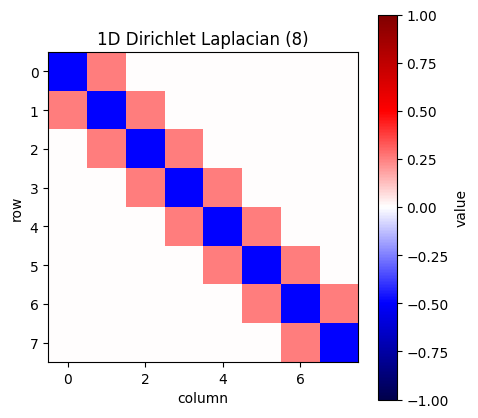

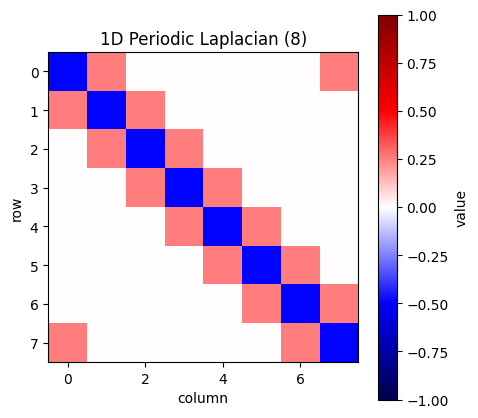

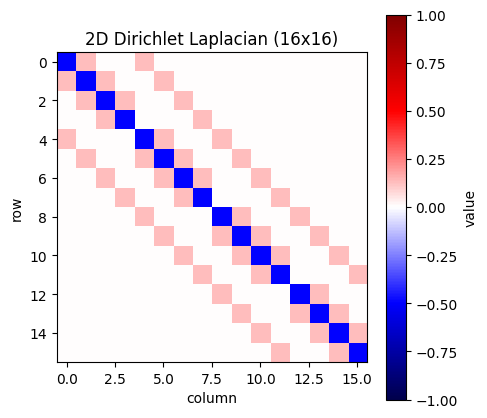

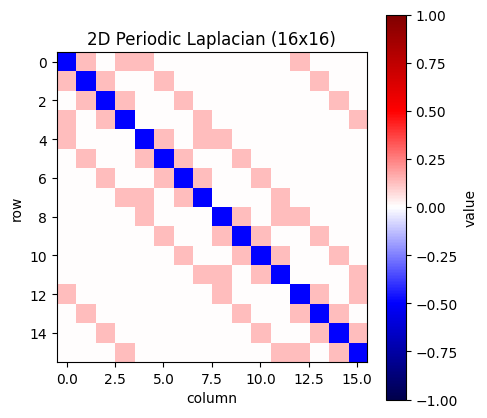

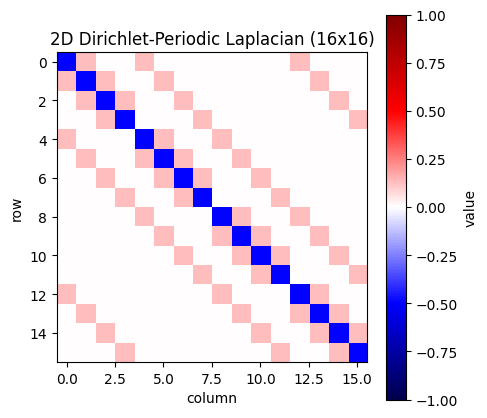

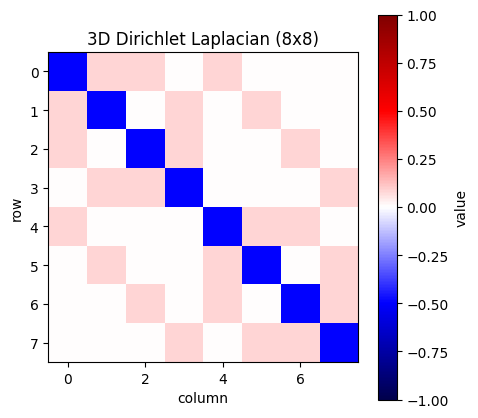

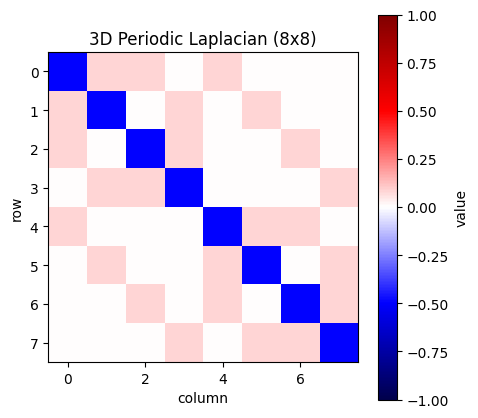

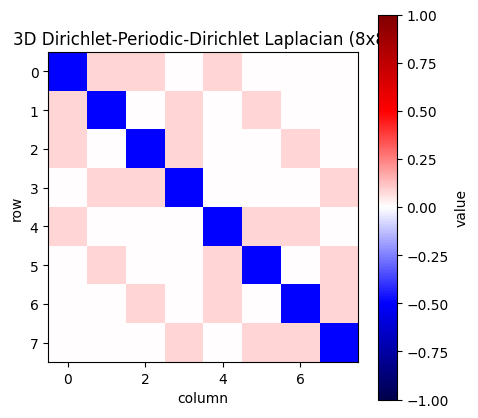

In [2]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from numpy.linalg import norm


def lap1d_fd(n, h=1.0, bc="dirichlet"):
    """
    Build 1D second-order finite-difference  (standard 3-point centered (central) finite-difference discretization for the second derivative) 
    Laplacian for `n` grid points with spacing `h` and boundary condition `bc`.

    Parameters
    ----------
    n : int
        Number of grid points (nodes) along the 1D domain (>=1).
    h : float
        Grid spacing.
    bc : {'dirichlet','neumann','periodic'}
        Boundary condition type:
          - 'dirichlet' : u=0 at boundaries (standard tridiagonal).
          - 'neumann'   : zero-flux (one-sided treatment at endpoints).
          - 'periodic'  : wrap-around neighbors (circulant/tridiagonal with corners).

    Returns
    -------
    A : scipy.sparse.csr_matrix, shape (n,n)
        Sparse 1D Laplacian matrix (second derivative approximation) scaled by 1/h^2.
    """
    if n < 1:
        raise ValueError("n must be >= 1")

    main = -2.0 / (h * h)
    off = 1.0 / (h * h)

    # tridiagonal base (LIL for easy element assignment)
    A = sp.diags(
        [off * np.ones(n - 1), main * np.ones(n), off * np.ones(n - 1)],
        offsets=[-1, 0, 1],
        shape=(n, n),
        format="lil",
    )

    if bc == "periodic":
        # wrap-around entries
        if n >= 2:
            A[0, n - 1] = off
            A[n - 1, 0] = off
        else:
            # n == 1: Laplacian on single periodic point is zero
            A[0, 0] = 0.0

    elif bc == "neumann":
        # zero-flux (reflect ghost): use one-sided second-derivative approx
        if n == 1:
            A[0, 0] = 0.0
        else:
            # first row: (-2 u0 + 2 u1)/h^2
            A[0, 0] = -2.0 / (h * h)
            A[0, 1] = 2.0 / (h * h)
            # last row symmetric
            A[n - 1, n - 1] = -2.0 / (h * h)
            A[n - 1, n - 2] = 2.0 / (h * h)

    else:
        # Dirichlet: standard tridiagonal (rows kept as is).
        pass

    return A.tocsr()


def generate_laplacian(shape, deltas=None, bcs=None, analytic_normalize=False):
    """
    Build separable FD Laplacian and optionally apply analytic normalization ().

    Parameters
    ----------
    shape : tuple of ints
        Number of grid points per axis (Nx, Ny, ...).
    deltas : tuple of floats or None
        Grid spacings per axis (hx, hy, ...). If None, uses 1.0 for each axis.
    bcs : str or tuple-of-str or None
        Boundary conditions per axis. If None, uses 'dirichlet' on all axes.
    analytic_normalize : bool
        If True, scale the assembled Laplacian by lambda_max = 4 * sum_i (1/h_i^2). 
        Returns (A_scaled, lambda_max). If False, returns A only. (We use the same analytical scaling factor as in the Sturm et al. 2025 paper.)

    Returns
    -------
    A or A_scaled
    """

    shape = tuple(shape)
    D = len(shape)
    if deltas is None:
        deltas = tuple([1.0] * D)
    else:
        deltas = tuple(deltas)

    if bcs is None:
        bcs = tuple(["dirichlet"] * D)
    elif isinstance(bcs, str):
        bcs = tuple([bcs] * D)
    else:
        bcs = tuple(bcs)

    # Build 1D operators
    ops_1d = [lap1d_fd(n, h, bc) for (n, h, bc) in zip(shape, deltas, bcs)]

    # Build Kronecker-sum: sum_k (I ⊗ ... ⊗ K_k ⊗ ... ⊗ I) # just like in the third reference paper (Sturm et al. 2015)
    total = None
    for axis, K in enumerate(ops_1d):
        # left identity: product of identity matrices for axes > axis
        kron_left = sp.eye(1, format="csr")
        for j in range(D - 1, axis, -1):
            kron_left = sp.kron(sp.eye(shape[j], format="csr"), kron_left, format="csr")

        # right identity: product for axes < axis
        kron_right = sp.eye(1, format="csr")
        for j in range(0, axis):
            kron_right = sp.kron(kron_right, sp.eye(shape[j], format="csr"), format="csr")

        term = sp.kron(kron_left, sp.kron(K, kron_right, format="csr"), format="csr")
        total = term if total is None else (total + term)

    A = total.tocsr()

    if analytic_normalize:  # again the same scaling factor as in the Sturm et al. 2025 paper
        # analytic lambda_max = 4 * sum_i (1 / h_i^2)
        lambda_max = 4.0 * sum((1.0 / (h * h)) for h in deltas)
        if lambda_max <= 0:
            raise ValueError("Computed lambda_max <= 0; check grid spacings.")
        A_scaled = A / lambda_max
        return A_scaled.tocsr()
    else:
        return A
    

# --- plotting helper---
def plot_heat_map(A, figsize=(5, 5), title="Matrix heatmap"):
    plt.figure(figsize=figsize)
    if sp.issparse(A):
        M = A.toarray()
    else:
        M = np.asarray(A)
    plt.imshow(M, cmap="seismic", interpolation="nearest", vmin=-1, vmax=1)
    plt.colorbar(label="value")
    plt.title(title)
    plt.xlabel("column")
    plt.ylabel("row")
    plt.show()


# --- demo ---
if __name__ == "__main__":
    # 1D Dirichlet (n=8) -> tridiagonal
    A1 = generate_laplacian((8,), deltas=(1.0,), bcs=("dirichlet",), analytic_normalize=True) # we already have the block encoding for this Camps et al. paper, this is a tridiagonal matrix
    print("\n1D dirichlet 8x8):\n", A1.toarray())

    # 1D Periodic (n=8) -> circulant
    A1p = generate_laplacian((8,), deltas=(1.0,), bcs=("periodic",), analytic_normalize=True) # we already have the block encoding for this Camps et al. paper, this is a banded circulant matrix
    print("\n1D periodic (8x8):\n", A1p.toarray())

    # 2D Dirichlet (4x4 grid -> 16x16 Laplacian: Block pentadiagonal)
    A2 = generate_laplacian((4, 4), deltas=(1.0, 1.0), bcs=("dirichlet", "dirichlet"), analytic_normalize=True) # we already have the block encoding for this Sunderhauff et al. paper, this is a block pentadiagonal matrix
    print("\n2D dirichlet (16x16):\n", A2.toarray())

    # 2D Periodic (4x4 grid -> 16x16 Laplacian)
    A2p = generate_laplacian((4, 4), deltas=(1.0, 1.0), bcs=("periodic", "periodic"), analytic_normalize=True)  # we already have the block encoding for this Sturm et al. 2025 paper
    print("\n2D periodic (16x16):\n", A2p.toarray())

    # 2D Dirichlet-Periodic (4x4 grid -> 16x16 Laplacian)
    A2dp = generate_laplacian((4, 4), deltas=(1.0, 1.0), bcs=("dirichlet", "periodic"), analytic_normalize=True) # TODO we don't have the block encoding for this mixed BCs case yet
    print("\n2D dirichlet-periodic (16x16):\n", A2dp.toarray())

    # 3D Dirichlet (2x2x2 grid -> 8x8 Laplacian)
    A3 = generate_laplacian((2, 2, 2), deltas=(1.0, 1.0, 1.0), bcs=("dirichlet", "dirichlet", "dirichlet"), analytic_normalize=True) # TODO we don't have the block encoding for this 3D case yet- this is basically trying to generalize the Sunderhauff et al. paper or Camps et al. paper (can we generalize it to N-dimensions?)
    print("\n3D dirichlet (8x8):\n", A3.toarray())

    # 3D Periodic (2x2x2 grid -> 8x8 Laplacian)
    A3p = generate_laplacian((2, 2, 2), deltas=(1.0, 1.0, 1.0), bcs=("periodic", "periodic", "periodic"), analytic_normalize=True) ## we already have the block encoding for this Sturm et al. 2025 paper (this is generalized to N-dimensions in the paper)
    print("\n3D periodic (8x8):\n", A3p.toarray())

    # 3D Dirichlet-Periodic-Dirichlet (2x2x2 grid -> 8x8 Laplacian)
    A3dpd = generate_laplacian((2, 2, 2), deltas=(1.0, 1.0, 1.0), bcs=("dirichlet", "periodic", "dirichlet"), analytic_normalize=True) # TODO we don't have the block encoding for this mixed BCs 3D case yet (even for mixed BC's in N-dim, can we generalize?)
    print("\n3D dirichlet-periodic-dirichlet (8x8):\n", A3dpd.toarray())



    # Visualizations of matrix structures
    plot_heat_map(A1, title="1D Dirichlet Laplacian (8)")
    plot_heat_map(A1p, title="1D Periodic Laplacian (8)")
    plot_heat_map(A2, title="2D Dirichlet Laplacian (16x16)")
    plot_heat_map(A2p, title="2D Periodic Laplacian (16x16)")
    plot_heat_map(A2dp, title="2D Dirichlet-Periodic Laplacian (16x16)")
    plot_heat_map(A3, title="3D Dirichlet Laplacian (8x8)")
    plot_heat_map(A3p, title="3D Periodic Laplacian (8x8)")
    plot_heat_map(A3dpd, title="3D Dirichlet-Periodic-Dirichlet Laplacian (8x8)")
